# Application: Displacement from Acceleration — Wind Turbine

This notebook applies the GP-based **double integration** framework to a structural health monitoring (SHM) problem: estimating the displacement of a wind turbine tower from measured accelerations.

**Task**: given noisy acceleration measurements $\ddot{x}(t)$, recover the displacement $x(t)$ and velocity $\dot{x}(t)$ via double integration.

Reproduces Figures 6 and 7 (Section 5) from:
> *Differentiation and Integration of Time Series via Gaussian Process Regression for Structural Health Monitoring Applications*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from gp_optimization import (
    optimize_hyperparams_Matern52_constrained,
    extract_smoothed_displacement_vel_accel,
)
import KalmanFilter_functions as KF
from plotting_functions import plot_states_with_zoom

## 1. Load Wind Turbine Data

The data comes from a 2-D numerical simulation of a wind turbine. The first 10 s are excluded (numerical transient), the mean displacement is subtracted (integration cannot recover a constant offset), and the signal is downsampled from 100 Hz to 20 Hz.

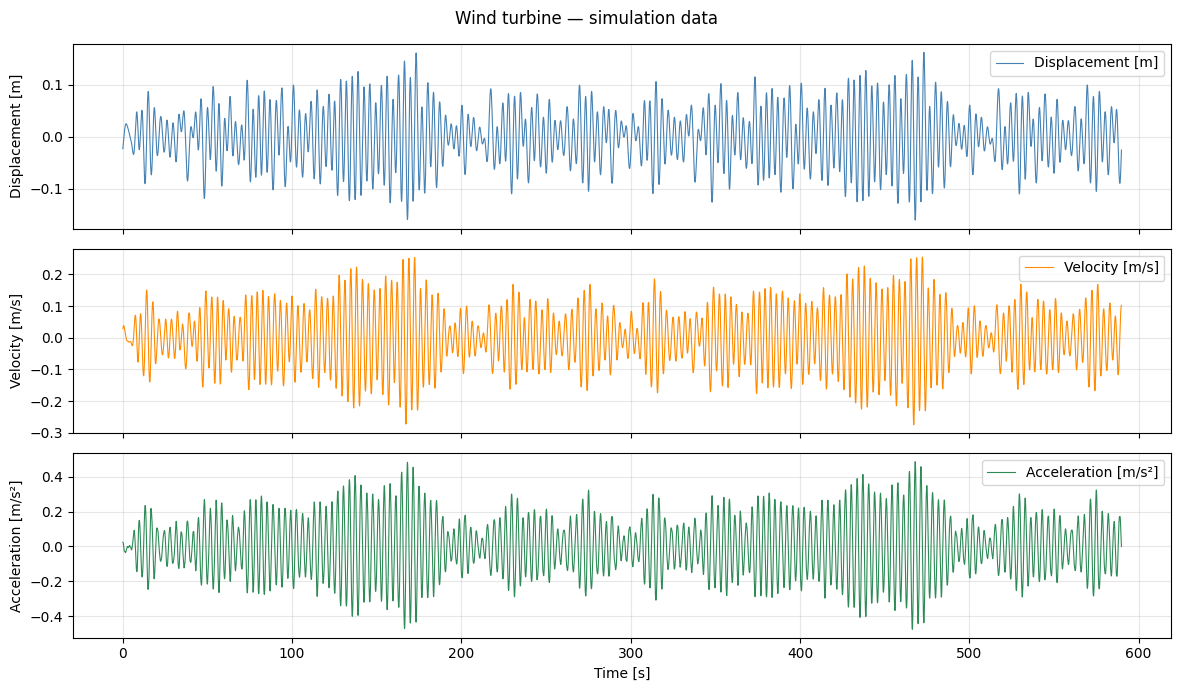

In [2]:
# Load simulation data (path relative to the notebooks/ folder)
data = np.loadtxt('windturbine2D.txt')

# Exclude initial transient (first 10 s at 100 Hz)
steps_to_exclude = int(10 / 0.01)
displacement_raw  = data[0, steps_to_exclude:]
velocity_raw      = data[1, steps_to_exclude:]
acceleration_raw  = data[2, steps_to_exclude:]

# Remove mean (cannot be recovered from integration)
displacement_raw -= np.mean(displacement_raw)

# Downsample by factor 5: 100 Hz -> 20 Hz
downsample = 5
true_displacement = displacement_raw[::downsample]
true_velocity     = velocity_raw[::downsample]
true_acceleration = acceleration_raw[::downsample]

fs = 100 / downsample   # 20 Hz
dt = 1.0 / fs
n_steps = len(true_displacement)
t = np.arange(n_steps) * dt

# Visualise
fig, axs = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, sig, label, color in zip(
    axs,
    [true_displacement, true_velocity, true_acceleration],
    ["Displacement [m]", "Velocity [m/s]", "Acceleration [m/s\u00b2]"],
    ["steelblue", "darkorange", "seagreen"]
):
    ax.plot(t, sig, color=color, lw=0.8, label=label)
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)
axs[-1].set_xlabel("Time [s]")
fig.suptitle("Wind turbine \u2014 simulation data")
plt.tight_layout()
plt.show()

## 2. Add Measurement Noise

In [3]:
# Add 5% Gaussian noise to the acceleration measurements
noise_fraction = 0.05
np.random.seed(456)
noise_std  = noise_fraction * np.std(true_acceleration)
meas_noisy = true_acceleration + noise_std * np.random.randn(n_steps)
R_true     = noise_std**2 * np.eye(1)

# Use a slightly optimistic R to stabilise the constrained optimisation
R_GP = R_true * (1 / 100)

## 3. Matérn 5/2 State-Space Model

In [4]:
def Matern52(l_f, sig_f, dt):
    """
    Matérn 5/2 state-space matrices (p=2).

    Parameters
    ----------
    l_f   : length scale
    sig_f : output standard deviation (sqrt of process variance)
    dt    : sampling interval

    Returns
    -------
    A, Qd, Pinf, D0, D1, D2
    """
    p  = 2
    ni = p + 0.5
    lambda_ = (2 * ni) ** 0.5 / l_f

    D0 = np.array([[1, 0, 0]])
    D1 = np.array([[0, 1, 0]])
    D2 = np.array([[0, 0, 1]])

    e   = np.exp(-lambda_ * dt)
    ldt = lambda_ * dt
    A = e * np.array([
        [1 + ldt + ldt**2 / 2,          dt * (1 + ldt),            dt**2 / 2            ],
        [-lambda_**3 * dt**2 / 2,        1 + ldt - ldt**2,           dt * (1 - ldt / 2)   ],
        [lambda_**4 * dt**2 / 2 - lambda_**3 * dt,
         lambda_**3 * dt**2 - 3 * lambda_**2 * dt,
         1 - 2 * ldt + ldt**2 / 2]
    ])

    Pinf = sig_f**2 * np.array([
        [1,               0,           -lambda_**2 / 3],
        [0,      lambda_**2 / 3,        0             ],
        [-lambda_**2 / 3, 0,             lambda_**4   ]
    ])

    Qd = Pinf - A @ Pinf @ A.T
    return A, Qd, Pinf, D0, D1, D2

## 4. Constrained Hyperparameter Optimization

For the double-integration case the problem is ill-conditioned: the noise variance is **fixed** (assumed known) and two equality constraints are imposed to pin the scale of the reconstructed displacement:

1. **Variance constraint**: $\sigma_f^2\,\lambda^4 = \text{Var}(\text{acceleration})$
2. **Std constraint**: $\text{std}(\hat{x}) = \sigma_f$

`observed_derivative = 2` means the GP observes the **second derivative** $\ddot{x}(t)$.

In [5]:
observed_derivative = 2  # observe acceleration → double-integrate to displacement

bounds_log = [
    (-1, 2),                                                          # log(l_f)
    (np.log(np.std(true_displacement) / 100),
     np.log(np.std(true_displacement) * 100)),                        # log(sig_f)
]
initial_params = np.array([10., 10. * np.std(true_displacement)])

params_opt, result = optimize_hyperparams_Matern52_constrained(
    meas_noisy.reshape(1, -1),
    dt,
    R_GP,
    initial_params,
    bounds_log,
    observed_derivative=observed_derivative,
    maxiter=100,
    ftol=1e-6,
    verbose=True,
)

l_f, sig_f = params_opt
print(f"Optimised  l_f={l_f:.4f}  sig_f={sig_f:.4f}")

Iteration 1  negLogLike: -27767.0  params: [7.3890561  0.54089067]


Iteration 2  negLogLike: -27767.0  params: [7.38905599 0.54089067]


Iteration 3  negLogLike: -27767.0  params: [7.3890561  0.54089068]


Iteration 4  negLogLike: 28473.0  params: [0.36787944 0.13629789]


Iteration 5  negLogLike: -28910.0  params: [5.47394739 0.47124576]


...

Iteration 30  negLogLike: -15218.0  params: [1.26555837 0.05383243]


Iteration 31  negLogLike: -15218.0  params: [1.26555706 0.05383232]


Iteration 32  negLogLike: -15218.0  params: [1.26555708 0.05383232]


Iteration 33  negLogLike: -15218.0  params: [1.26555706 0.05383232]


Optimization terminated successfully    (Exit mode 0)
            Current function value: -15217.772346162883
            Iterations: 10
            Function evaluations: 33
            Gradient evaluations: 10
Optimized parameters: [1.26555706 0.05383232]
Final neg-log-likelihood: -15217.772346162883
Optimised  l_f=1.2656  sig_f=0.0538


## 5. GP Regression via Kalman Filter + RTS Smoother

P:\Postdoc_2025_2027\2026_02_February\revision_paper_GP\GP‑DiffInt\notebooks\plotting_functions.py:140: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best", fontsize=fontsize_legends)


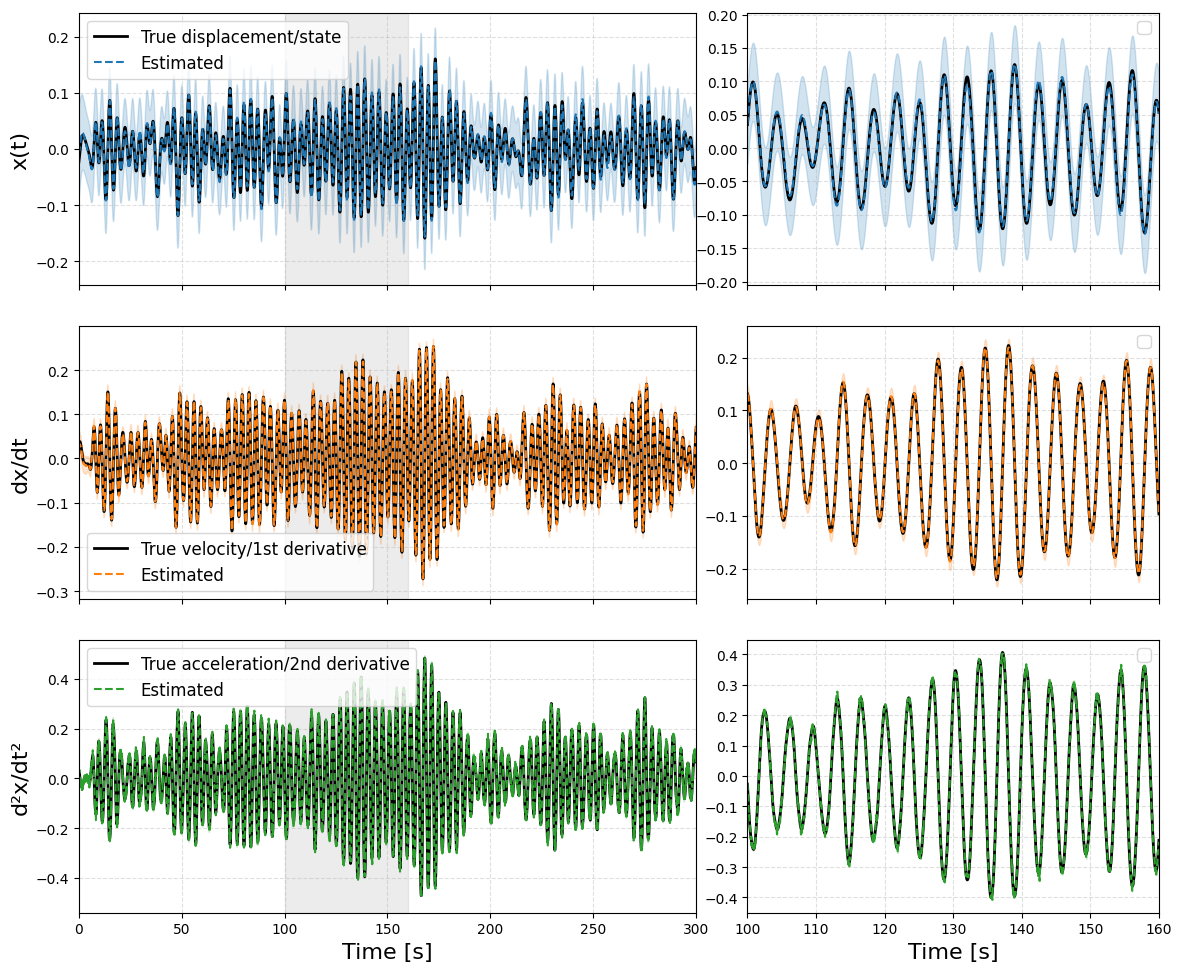

In [6]:
R_opt = R_GP

A, Qd, Pinf, D0, D1, D2 = Matern52(l_f, sig_f, dt)
H = [D0, D1, D2][observed_derivative]

# Kalman filter
zf, Pf = KF.kf_full_estimation(A, H, Qd, R_opt, meas_noisy.reshape(1, -1),
                                z0=np.zeros(3), P0=Pinf, return_nll=False)

# RTS smoother
zs, Ps = KF.rtss_full_estimation(A, zf, Pf, Qd)

# Extract all three states and their marginal variances
(displacement, displacement_variance,
 velocity,     velocity_variance,
 acceleration, acceleration_variance) = extract_smoothed_displacement_vel_accel(
     zs, Ps, D0, D1, D2
 )

# Plot
plot_states_with_zoom(
    t,
    true_displacement.reshape(-1, 1),
    np.vstack((true_velocity, true_acceleration)).T,
    displacement, velocity, acceleration,
    displacement_variance, velocity_variance, acceleration_variance,
    t_full_min=0.0,  t_full_max=300,
    t_zoom_min=100,  t_zoom_max=160,
    fontsize_axes=16, fontsize_legends=12,
    save_path=None,  figsize=(12, 10)
)
plt.show()

## 6. (Optional) Comparison with Classical Double-Integration Methods

Compares GP results against:
- **Double integration + polynomial detrending**
- **Frequency-domain double integration** (windowed DFT + high-pass)

C:\Users\lucag\AppData\Local\Temp\ipykernel_27124\1156179584.py:9: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(t, displacement, polynomial_degree)


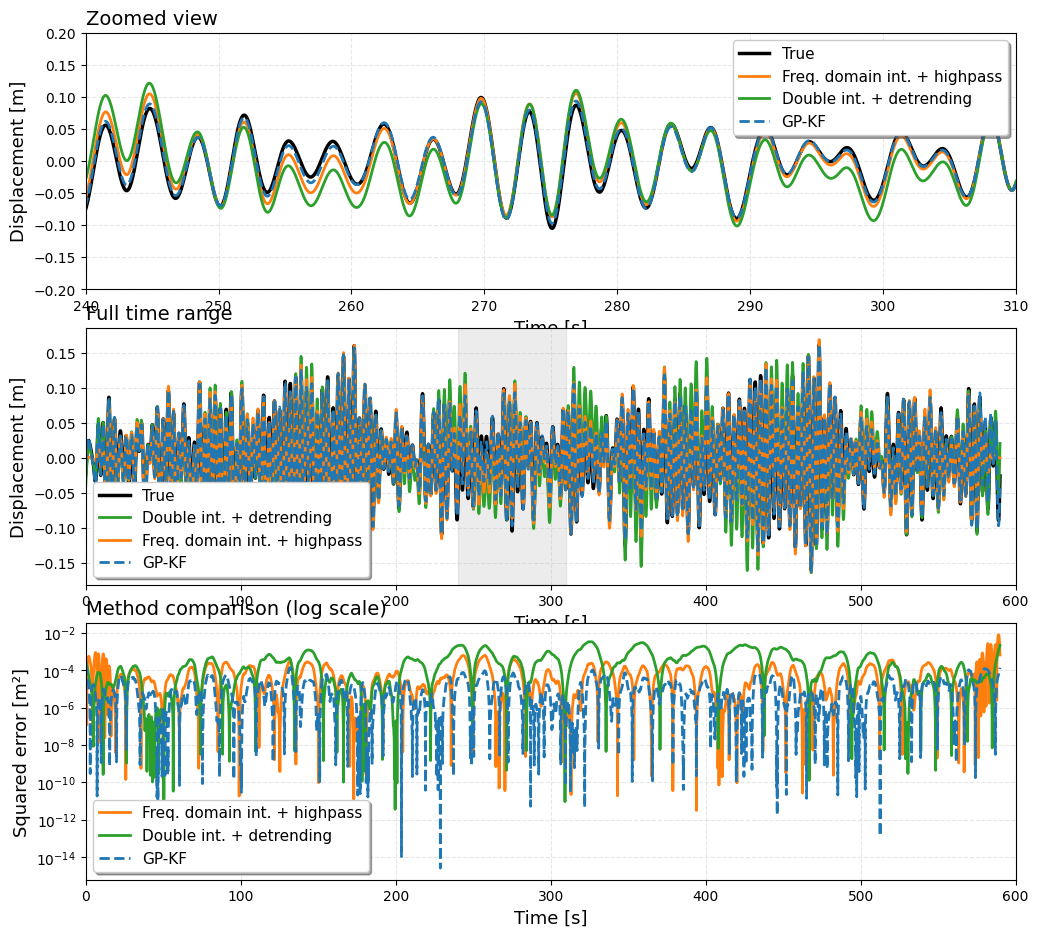

In [7]:
from plotting_functions import plot_integration_method_comparison
from scipy.integrate import cumulative_trapezoid
from scipy import signal

# --- 1. Double integration + polynomial detrend ---
def acc2disp_detrend(t, acceleration, dt, polynomial_degree):
    velocity     = cumulative_trapezoid(acceleration, dx=dt, initial=0)
    displacement = cumulative_trapezoid(velocity,     dx=dt, initial=0)
    coefficients = np.polyfit(t, displacement, polynomial_degree)
    trend        = np.polyval(coefficients, t)
    return displacement - trend

displacement_detrended = acc2disp_detrend(
    t, meas_noisy.flatten(), dt, polynomial_degree=30
)

# --- 2. Frequency-domain double integration (windowed DFT) ---
def highpass_filter(data, cutoff_freq, fs, order=4):
    nyq    = 0.5 * fs
    b, a   = signal.butter(order, cutoff_freq / nyq, btype='high', analog=False)
    return signal.filtfilt(b, a, data)

def long_dft_integrate(input_signal, dt, highpass_cutoff=None):
    fs = 1.0 / dt
    L  = len(input_signal)
    sig = input_signal.copy()
    if highpass_cutoff is not None:
        sig = highpass_filter(sig, highpass_cutoff, fs)
    sig -= np.mean(sig)
    X    = np.fft.rfft(sig, n=2 * L)
    freq = np.fft.rfftfreq(2 * L, dt)
    H    = np.zeros(L + 1, dtype=complex)
    H[0] = 0
    omega = 2 * np.pi * freq[1:]
    H[1:] = 1.0 / (1j * omega)
    y = np.fft.irfft(X * H, n=2 * L)[:L]
    return signal.detrend(y, type='linear')

def apply_edge_window(sig, m):
    windowed = sig.copy()
    if m > 0 and m <= len(sig) // 2:
        hann_rise = np.hanning(2 * m)[:m]
        hann_fall = np.hanning(2 * m)[m:]
        windowed[:m]  *= hann_rise
        windowed[-m:] *= hann_fall
    return windowed

acc_windowed = apply_edge_window(meas_noisy.flatten(), int(20 / dt))
vel_fd  = long_dft_integrate(acc_windowed, dt, highpass_cutoff=0.0222)
disp_fd = long_dft_integrate(vel_fd,       dt, highpass_cutoff=0.0222)

fig, (ax_full, ax_zoom, ax_error) = plot_integration_method_comparison(
    t=t,
    u=true_displacement,
    displacement_GP=displacement,
    displacement_detrended=displacement_detrended,
    displacement_fourier=disp_fd,
    u_mean=true_displacement.mean(),
    t_full_min=0, t_full_max=600,
    t_zoom_min=240, t_zoom_max=310,
    y_zoom_lim=(-0.2, 0.2),
    save_path=None,
)
plt.show()